In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
data = pd.read_csv(r'C:\Users\julia\OneDrive\Escritorio\Fund_Data_Analysis\Insurance\medical_insurance.csv')

In [3]:
data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
data.shape

(2772, 7)

In [5]:
for col in data.columns:
  print(col)

age
sex
bmi
children
smoker
region
charges


In [6]:
data.dtypes

,0
age,int64
sex,object
bmi,float64
children,int64
smoker,object
region,object
charges,float64


In [ ]:
# data.drop(columns=['PassengerId', 'Name', 'Ticket'], inplace=True)

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2772 entries, 0 to 2771
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       2772 non-null   int64  
 1   sex       2772 non-null   object 
 2   bmi       2772 non-null   float64
 3   children  2772 non-null   int64  
 4   smoker    2772 non-null   object 
 5   region    2772 non-null   object 
 6   charges   2772 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 151.7+ KB


In [8]:
data.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [9]:
# (data.isnull().sum()/data.shape[0]).round(2)

In [4]:
text_columns = data.select_dtypes(include=['object']).columns.tolist()
numeric_columns = data.select_dtypes(include=['int64', 'float64']).columns.tolist()

# columns_to_move = ['Survived','Pclass']

# for col in columns_to_move:
#     if col in numeric_columns:
#         numeric_columns.remove(col)
#     if col not in text_columns:
#         text_columns.append(col)

print("Text Columns:", text_columns)
print("Numeric Columns:", numeric_columns)

Text Columns: ['sex', 'smoker', 'region']
Numeric Columns: ['age', 'bmi', 'children', 'charges']


# Análisis univariante

Entender individualmente cada variable (COLS)


## Variables categóricas


--- Análisis para la columna: sex ---
Número de categorías únicas: 2
Conteo de valores:


sex
male      1406
female    1366
Name: count, dtype: int64


Distribución de valores (normalizada):


sex
male      0.507
female    0.493
Name: proportion, dtype: float64

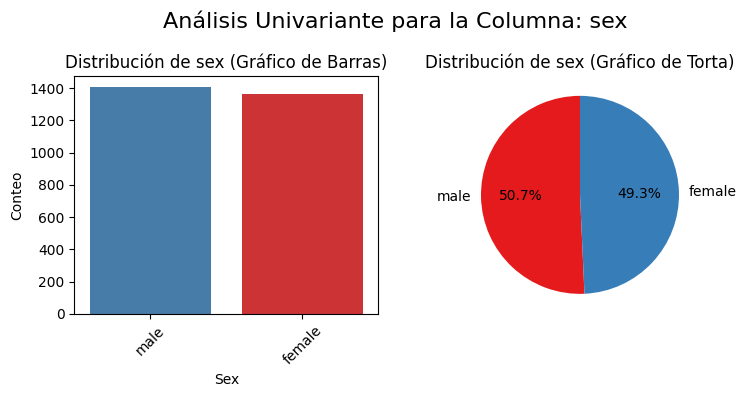


--- Análisis para la columna: smoker ---
Número de categorías únicas: 2
Conteo de valores:


smoker
no     2208
yes     564
Name: count, dtype: int64


Distribución de valores (normalizada):


smoker
no     0.797
yes    0.203
Name: proportion, dtype: float64

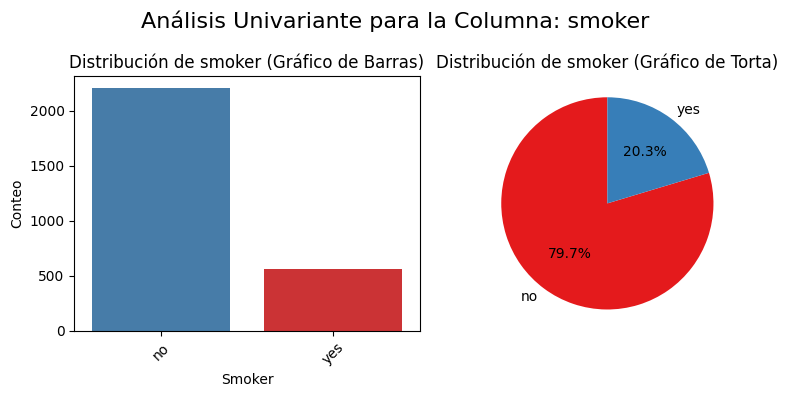


--- Análisis para la columna: region ---
Número de categorías únicas: 4
Conteo de valores:


region
southeast    766
southwest    684
northwest    664
northeast    658
Name: count, dtype: int64


Distribución de valores (normalizada):


region
southeast    0.276
southwest    0.247
northwest    0.240
northeast    0.237
Name: proportion, dtype: float64

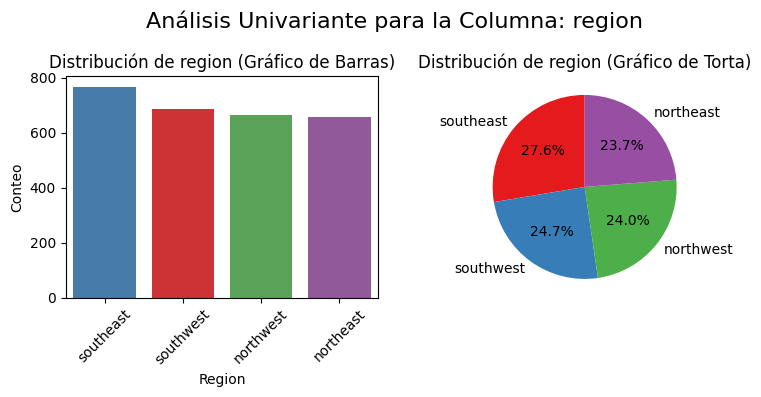

In [6]:
for col in text_columns:
    print(f"\n--- Análisis para la columna: {col} ---")
    print(f"Número de categorías únicas: {len(data[col].unique())}")

    # Display value counts
    print("Conteo de valores:")
    display(data[col].value_counts())
    print("\nDistribución de valores (normalizada):")
    display(data[col].value_counts(normalize=True).round(3))

    # if col in ['Cabin']:
    #   continue
    # Create subplots for bar and pie charts
    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    fig.suptitle(f'Análisis Univariante para la Columna: {col}', fontsize=16)

    # Bar chart
    sns.countplot(data=data, x=col, palette='Set1', ax=axes[0], hue=col, legend=False, order=data[col].value_counts().index)
    axes[0].set_title(f'Distribución de {col} (Gráfico de Barras)')
    axes[0].set_xlabel(col.replace('_', ' ').title())
    axes[0].set_ylabel('Conteo')
    axes[0].tick_params(axis='x', rotation=45)

    # Pie chart
    counts = data[col].value_counts()
    axes[1].pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette('Set1'))
    axes[1].set_title(f'Distribución de {col} (Gráfico de Torta)')
    axes[1].axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.

    plt.tight_layout()
    plt.show()

## Variables numéricas

In [7]:
data[numeric_columns].describe()

,age,bmi,children,charges
count,2772.000000,2772.000000,2772.000000,2772.000000
mean,39.109668,30.701349,1.101732,13261.369959
std,14.081459,6.129449,1.214806,12151.768945
min,18.000000,15.960000,0.000000,1121.873900
25%,26.000000,26.220000,0.000000,4687.797000
50%,39.000000,30.447500,1.000000,9333.014350
75%,51.000000,34.770000,2.000000,16577.779500
max,64.000000,53.130000,5.000000,63770.428010



--- Análisis para la columna: age ---
Estadísticas Descriptivas:


count    2772.000000
mean       39.109668
std        14.081459
min        18.000000
25%        26.000000
50%        39.000000
75%        51.000000
max        64.000000
Name: age, dtype: float64

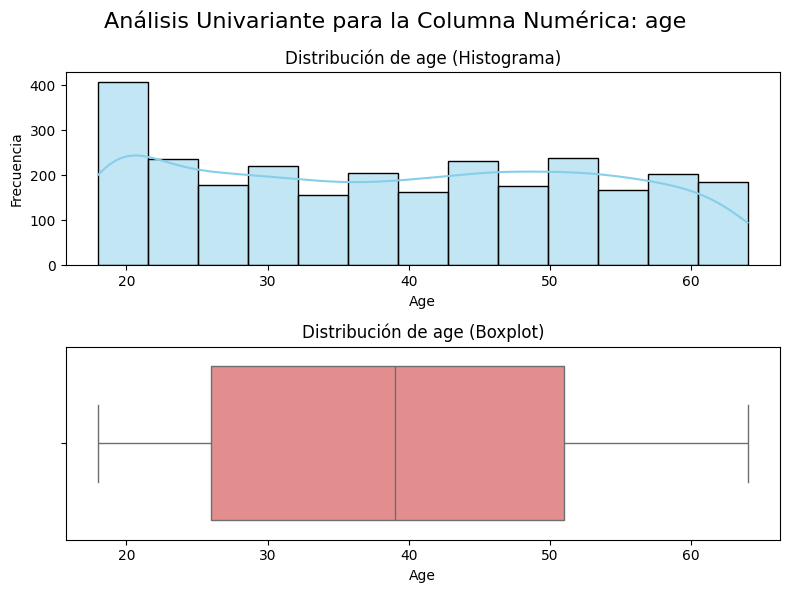


--- Análisis para la columna: bmi ---
Estadísticas Descriptivas:


count    2772.000000
mean       30.701349
std         6.129449
min        15.960000
25%        26.220000
50%        30.447500
75%        34.770000
max        53.130000
Name: bmi, dtype: float64

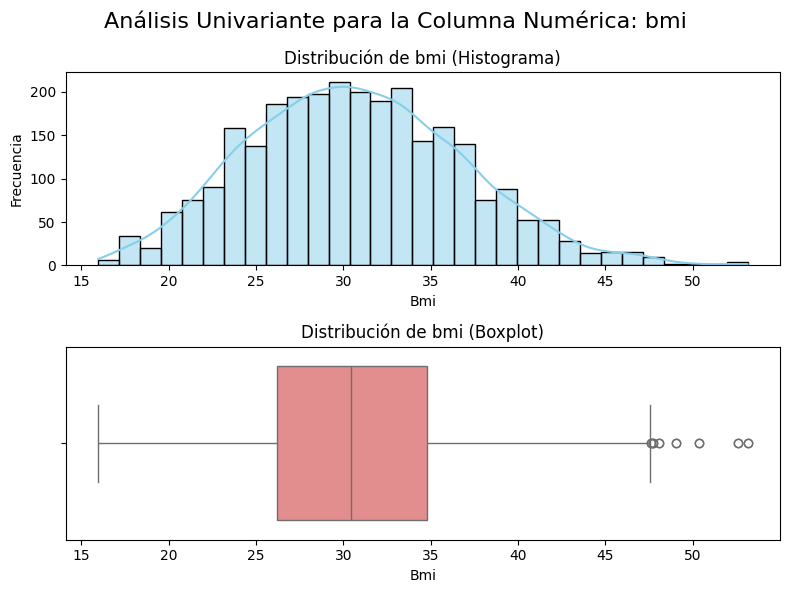


--- Análisis para la columna: children ---
Estadísticas Descriptivas:


count    2772.000000
mean        1.101732
std         1.214806
min         0.000000
25%         0.000000
50%         1.000000
75%         2.000000
max         5.000000
Name: children, dtype: float64

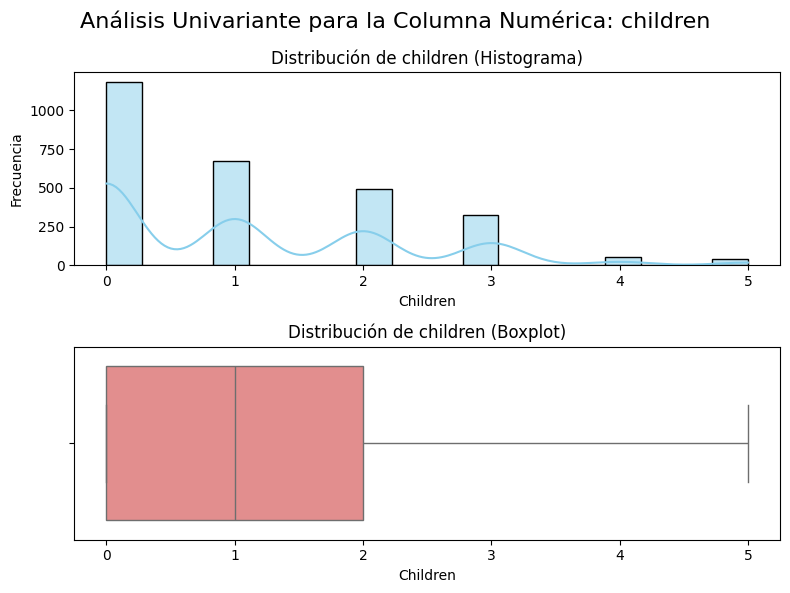


--- Análisis para la columna: charges ---
Estadísticas Descriptivas:


count     2772.000000
mean     13261.369959
std      12151.768945
min       1121.873900
25%       4687.797000
50%       9333.014350
75%      16577.779500
max      63770.428010
Name: charges, dtype: float64

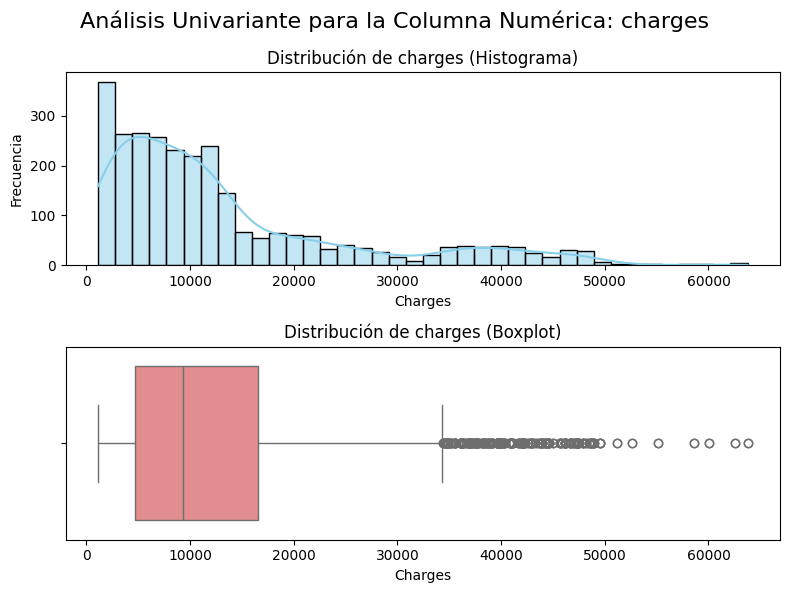

In [9]:
for col in numeric_columns:
    print(f"\n--- Análisis para la columna: {col} ---")
    print("Estadísticas Descriptivas:")
    display(data[col].describe())

    # Create subplots for histogram and boxplot
    fig, axes = plt.subplots(2, 1, figsize=(8, 6)) # 2 rows, 1 column
    fig.suptitle(f'Análisis Univariante para la Columna Numérica: {col}', fontsize=16)

    # Histogram
    sns.histplot(data=data, x=col, kde=True, ax=axes[0], color='skyblue')
    axes[0].set_title(f'Distribución de {col} (Histograma)')
    axes[0].set_xlabel(col.replace('_', ' ').title())
    axes[0].set_ylabel('Frecuencia')

    # Boxplot
    sns.boxplot(data=data, x=col, ax=axes[1], color='lightcoral')
    axes[1].set_title(f'Distribución de {col} (Boxplot)')
    axes[1].set_xlabel(col.replace('_', ' ').title())

    plt.tight_layout() # Adjust layout to prevent suptitle overlap
    plt.show()

# Análisis bivariante

## Numérico

In [10]:
data[numeric_columns].corr()

,age,bmi,children,charges
age,1.000000,0.113048,0.037574,0.298624
bmi,0.113048,1.000000,-0.001492,0.199846
children,0.037574,-0.001492,1.000000,0.066442
charges,0.298624,0.199846,0.066442,1.000000


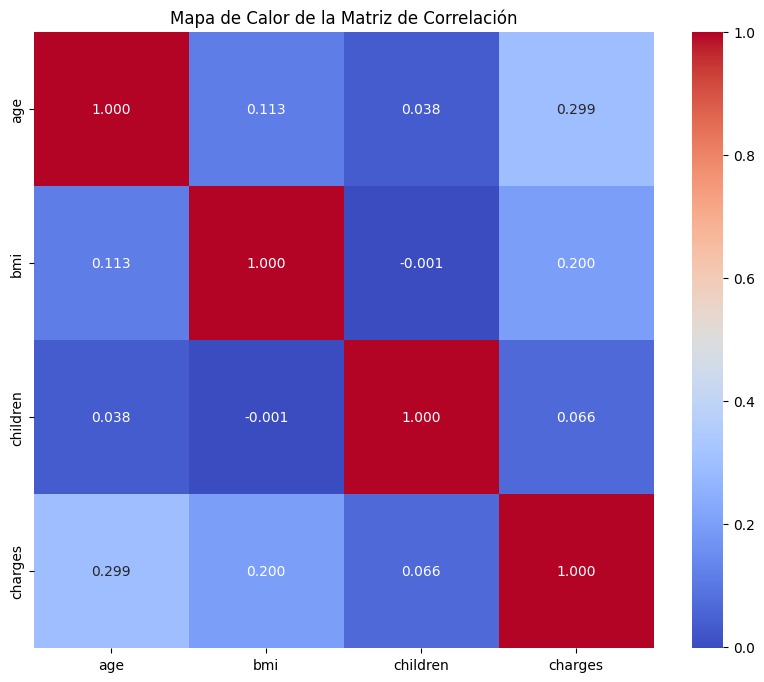

In [11]:
plt.figure(figsize=(10, 8))
sns.heatmap(data[numeric_columns].corr(), annot=True, cmap='coolwarm', fmt=".3f")
plt.title('Mapa de Calor de la Matriz de Correlación')
plt.show()

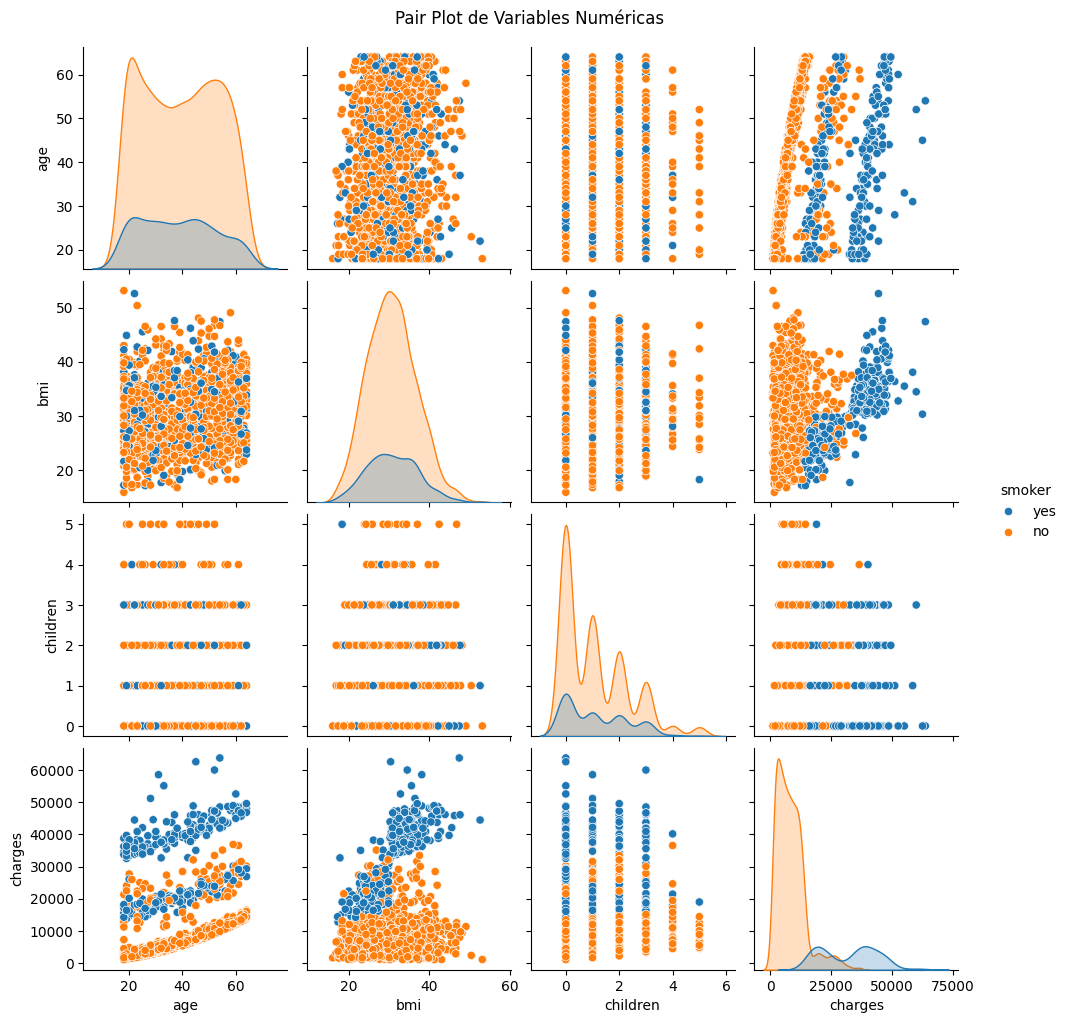

In [ ]:
sns.pairplot(data[numeric_columns+['smoker']], hue='smoker') #Paradoja de simpson
plt.suptitle('Pair Plot de Variables Numéricas', y=1.02) # Ajusta el título para que no se solape
plt.show()

## Categóricas

In [13]:
text_columns

['sex', 'smoker', 'region']

In [14]:
columna_cat_1 = 'smoker'
columna_cat_2 = 'sex'

crosstab_result = pd.crosstab(data[columna_cat_1], data[columna_cat_2])

print(f"Tabla de contingencia entre '{columna_cat_1}' y '{columna_cat_2}':")
display(crosstab_result)

# También puedes ver la distribución normalizada
print(f"\nTabla de contingencia normalizada entre '{columna_cat_1}' y '{columna_cat_2}':")
display(pd.crosstab(data[columna_cat_1], data[columna_cat_2], normalize=True).round(3))

Tabla de contingencia entre 'smoker' y 'sex':


sex,female,male
smoker,,
no,1134,1074
yes,232,332



Tabla de contingencia normalizada entre 'smoker' y 'sex':


sex,female,male
smoker,,
no,0.409,0.387
yes,0.084,0.120


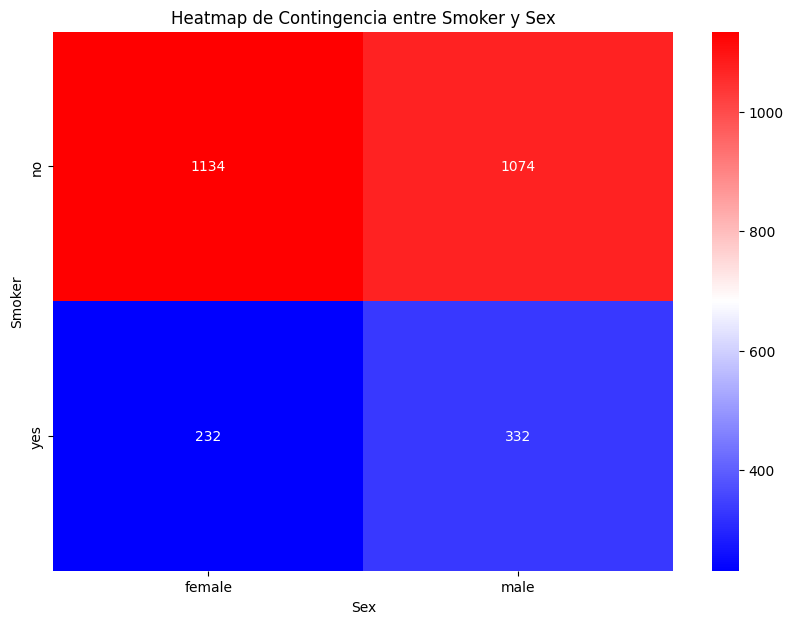

In [16]:
plt.figure(figsize=(10, 7))
sns.heatmap(crosstab_result, annot=True, fmt='d', cmap='bwr')
plt.title(f'Heatmap de Contingencia entre {columna_cat_1.replace("_", " ").title()} y {columna_cat_2.replace("_", " ").title()}')
plt.xlabel(columna_cat_2.replace("_", " ").title())
plt.ylabel(columna_cat_1.replace("_", " ").title())
plt.show()

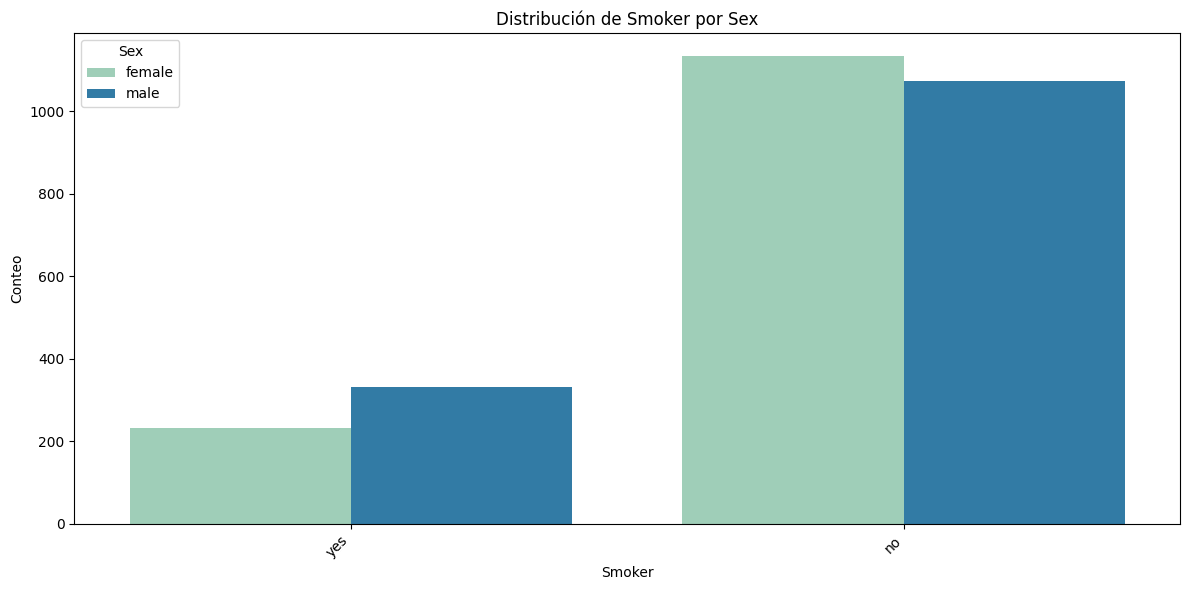

In [36]:
columna_cat_1 = 'smoker'
columna_cat_2 = 'sex'

plt.figure(figsize=(12, 6))
sns.countplot(data=data, x=columna_cat_1, hue=columna_cat_2, palette='YlGnBu')
plt.title(f'Distribución de {columna_cat_1.replace('_', ' ').title()} por {columna_cat_2.replace('_', ' ').title()}')
plt.xlabel(columna_cat_1.replace('_', ' ').title())
plt.ylabel('Conteo')
plt.xticks(rotation=45, ha='right')
plt.legend(title=columna_cat_2.replace('_', ' ').title())
plt.tight_layout()
plt.show()

## Categórico + Numérico

In [ ]:
numeric_columns

['Age', 'SibSp', 'Parch', 'Fare']

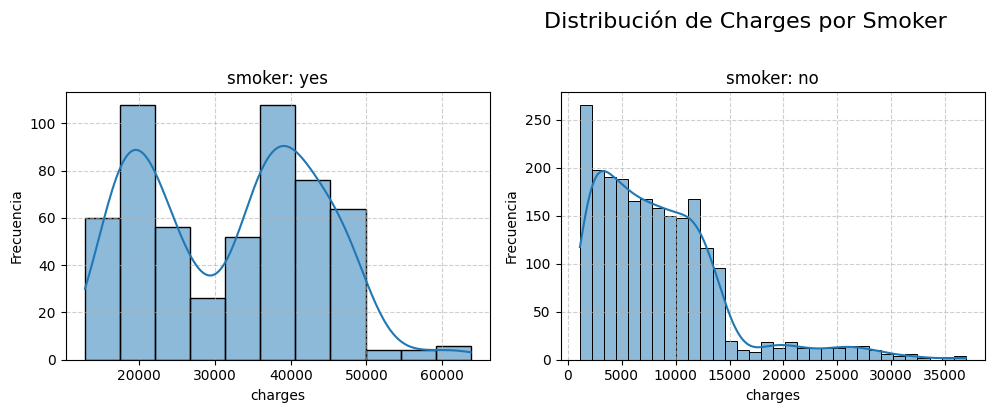

In [37]:
columna_categorica = 'smoker'
columna_numerica = 'charges'

unique_categories = data[columna_categorica].unique()
num_categories = len(unique_categories)

# Determine grid size for subplots
num_cols = 3 # You can adjust this number
num_rows = (num_categories + num_cols - 1) // num_cols

fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows))
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

for i, category in enumerate(unique_categories):
    subset_data = data[data[columna_categorica] == category]
    sns.histplot(data=subset_data, x=columna_numerica, kde=True, ax=axes[i]) # Removed palette argument
    axes[i].set_title(f'{columna_categorica}: {category}')
    axes[i].set_xlabel(f'{columna_numerica}')
    axes[i].set_ylabel('Frecuencia')
    axes[i].grid(True, linestyle='--', alpha=0.6)

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle(f'Distribución de {columna_numerica.replace("_", " ").title()} por {columna_categorica.replace("_", " ").title()}', fontsize=16, y=1.02)
plt.tight_layout() # Adjust layout to prevent suptitle overlap
plt.show()

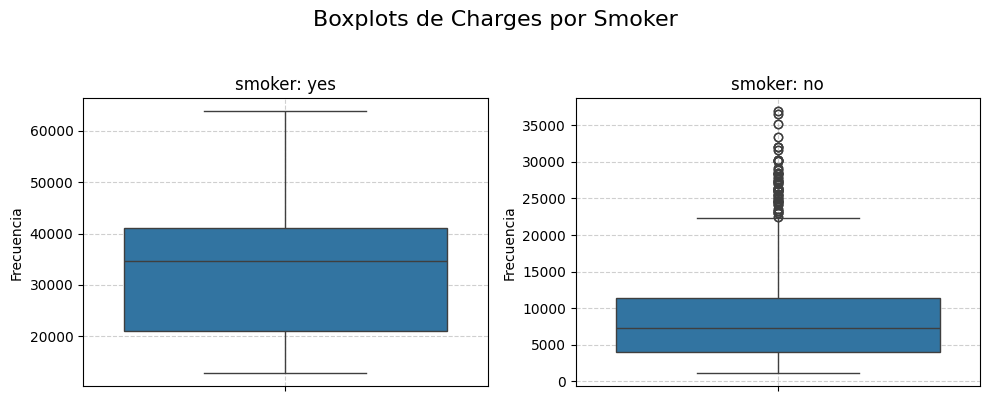

In [38]:
columna_categorica = 'smoker'
columna_numerica = 'charges'

unique_categories = data[columna_categorica].unique()
num_categories = len(unique_categories)

# Determine grid size for subplots
num_cols = 2 # You can adjust this number
num_rows = (num_categories + num_cols - 1) // num_cols
# num_rows = (7 + 3 -1) // 3 = (9) // 3  = 3

fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows))
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

for i, category in enumerate(unique_categories):
    subset_data = data[data[columna_categorica] == category]
    sns.boxplot(data=subset_data, y=columna_numerica, ax=axes[i]) # Removed palette argument
    axes[i].set_title(f'{columna_categorica}: {category}')
    axes[i].set_ylabel('Frecuencia')
    axes[i].set_xlabel('') # Boxplots don't usually need an x-label for single category
    axes[i].grid(True, linestyle='--', alpha=0.6)

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle(f'Boxplots de {columna_numerica.replace("_", " ").title()} por {columna_categorica.replace("_", " ").title()}', fontsize=16, y=1.02)
plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to prevent suptitle overlap
plt.show()